# Data Generation using PCA and Gaussian Mixture Models

** Nada Belarbi  
**Objective:** Dimensionality reduction, probabilistic modeling, and synthetic data generation  


## Introduction

In many machine learning applications, data are high-dimensional and complex, which makes both modeling and visualization difficult.  
This work session focuses on the generation of synthetic data from a dataset of curves using **dimensionality reduction** and **probabilistic modeling** techniques.

The dataset considered in this TP consists of **Gaussian curves**, each curve being discretized over a fixed grid. Each curve can therefore be seen as a high-dimensional vector.

The objectives of this work session are:
- to analyze the structure of the data using **Principal Component Analysis (PCA)**,
- to reduce the dimensionality while preserving most of the information,
- to model the distribution of the curves in the reduced space using a **Gaussian Mixture Model (GMM)**,
- and finally, to generate **new realistic curves** from the learned model.

This notebook follows the complete pipeline from data generation to synthetic data analysis, with detailed interpretations of each result.


In [35]:
import numpy as np
import matplotlib.pyplot as plt

from create_gaussian_curves import create_gaussian_curves
from analyze_pca import analyze_pca, compute_pca, reconstruct_curves
from gmm_clustering import cluster_with_gmm
from curve_sampling import sample_new_curves
from curve_metrics import extract_curve_features, summary_stats

np.random.seed(42)
plt.rcParams["figure.dpi"] = 120


## A) Simulations: generate a dataset of Gaussian curves

## A. Data Generation

The first step of this work consists in generating a dataset of curves that will serve as our reference data.

Each curve is generated as a Gaussian probability density function, parameterized by:
- a mean μ,
- a standard deviation σ.

To introduce variability in the dataset, the parameters μ and σ are randomly sampled for each curve.  
A small amount of Gaussian noise is also added to make the data more realistic.

As a result:
- each curve is represented by a vector of fixed length,
- the complete dataset can be seen as a matrix of shape (N, number of discretization points).

This synthetic dataset allows us to fully control the data distribution while still working with non-trivial high-dimensional objects.


In [2]:
# Fix simulation parameters values 
mux, sdx = 0.0, 1.0          # distribution of mu
ax, bx   = 7.0, 0.2          # distribution of sigma: sigma = ax + bx * |N(0,1)|
N        = 1000              # number of curves
xmin, xmax = -10, 10
nbx = 300
sd_noise = 0.00              # set >0 to test robustness to noise

# Generate the values mu_i, sigma_i, i=1,...,N
mu = np.random.normal(loc=mux, scale=sdx, size=N)
sd = ax + bx * np.abs(np.random.normal(size=N))

x, Y = create_gaussian_curves(mu, sd, N, xmin, xmax, nbx, sd_noise)
x.shape, Y.shape


((300,), (1000, 300))

### Visualization of the Generated Curves

The figure below shows several randomly selected curves from the generated dataset.

We observe that:
- all curves share a common Gaussian-like shape,
- their positions vary according to the mean μ,
- their widths vary according to the standard deviation σ,
- the added noise slightly perturbs the curves without destroying their global structure.

This confirms that the dataset is coherent and well-suited for studying dimensionality reduction and generative modeling.


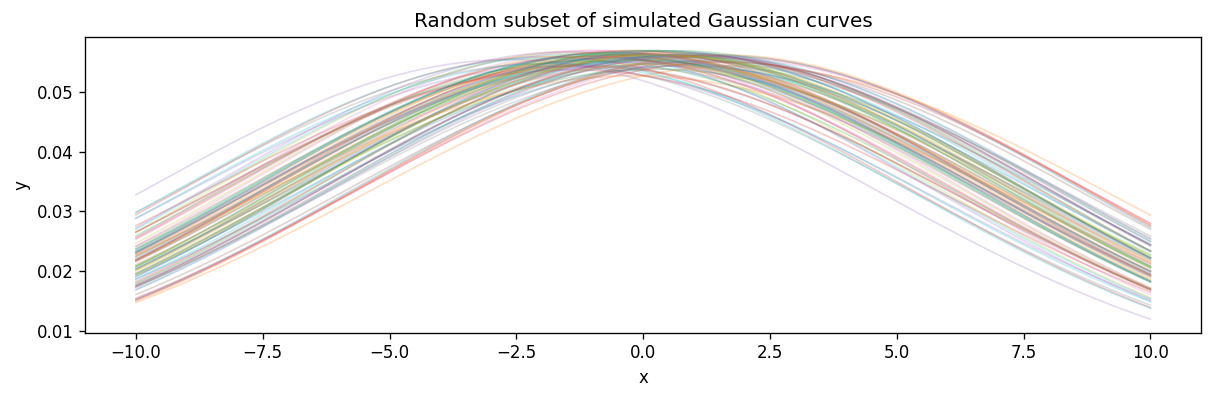

In [3]:
# Plot a subset of curves
fig, ax = plt.subplots(figsize=(12, 3.2))
for i in range(80):
    ax.plot(x, Y[i], alpha=0.25, linewidth=1)
ax.set_title("Random subset of simulated Gaussian curves")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()


### Feature sanity check (estimated mu/sigma from curves)

In [4]:
feat = extract_curve_features(x, Y)
print("mu_hat:", summary_stats(feat["mu_hat"]))
print("sigma_hat:", summary_stats(feat["sigma_hat"]))


mu_hat: {'mean': 0.009434327259719757, 'std': 0.4881394872154969, 'min': -1.6145602951620108, 'median': 0.012731550434916845, 'max': 1.8189786042373577}
sigma_hat: {'mean': 5.054726454424106, 'std': 0.027746056922727382, 'min': 4.9378850545781585, 'median': 5.052092987230056, 'max': 5.1501330205822935}


## B. Principal Component Analysis (PCA)

Each curve in the dataset is represented by a high-dimensional vector.  
Directly modeling such high-dimensional data is computationally expensive and often unnecessary.

Principal Component Analysis (PCA) is used here to:
- identify the main directions of variability in the data,
- reduce the dimensionality while preserving as much information as possible,
- provide a compact representation of the curves.

Before applying PCA, the data are standardized to ensure that all dimensions contribute equally to the analysis.


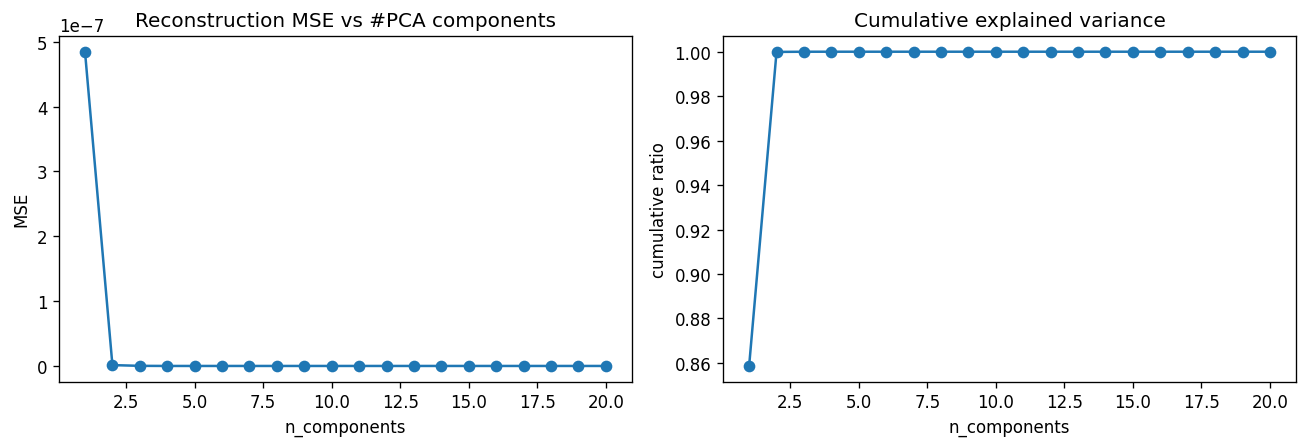

2

In [5]:
max_components = 20

Z, mse_errors, explained_variance_ratio, pca, scaler = analyze_pca(
    Y, n_comp_max=max_components, scale_data=True
)

cum_var = np.cumsum(explained_variance_ratio)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(range(1, max_components+1), mse_errors, marker="o")
axes[0].set_title("Reconstruction MSE vs #PCA components")
axes[0].set_xlabel("n_components")
axes[0].set_ylabel("MSE")

axes[1].plot(range(1, max_components+1), cum_var, marker="o")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("n_components")
axes[1].set_ylabel("cumulative ratio")

plt.tight_layout()
plt.show()

# Choose n_comp for the rest of the TP (heuristic: first k with >= 0.99 variance)
n_comp = int(np.argmax(cum_var >= 0.99) + 1) if np.any(cum_var >= 0.99) else 10
n_comp


### Reconstruction Error Analysis

To evaluate the quality of the PCA representation, we analyze the reconstruction error as a function of the number of principal components.

The reconstruction error is measured using the Mean Squared Error (MSE) between the original curves and their reconstructions.

From the plotted curve, we observe that:
- the reconstruction error decreases rapidly when the first components are added,
- after a certain number of components, the error stabilizes,
- adding more components beyond this point yields diminishing returns.

This behavior indicates that most of the relevant information in the curves is captured by a small number of principal components.


### Explained Variance Ratio

The explained variance ratio provides another perspective on the effectiveness of PCA.

It measures the proportion of the total variance explained by each principal component.

The cumulative explained variance shows that:
- the first few components explain the majority of the variance,
- higher-order components mainly capture fine-scale variations and noise.

This confirms that the intrinsic dimensionality of the dataset is much lower than the original dimensionality of the curves.


### PCA space visualization (PC1 vs PC2) and reconstructions

### Curve Reconstruction

To visually assess the quality of the PCA approximation, original curves are compared with their reconstructions using a limited number of components.

We observe that:
- with very few components, the reconstructed curves are overly smooth and lose detail,
- as the number of components increases, the reconstructed curves become increasingly faithful,
- beyond a certain number of components, reconstructions are almost indistinguishable from the original curves.

This visual analysis complements the quantitative error measurements and validates the PCA model.


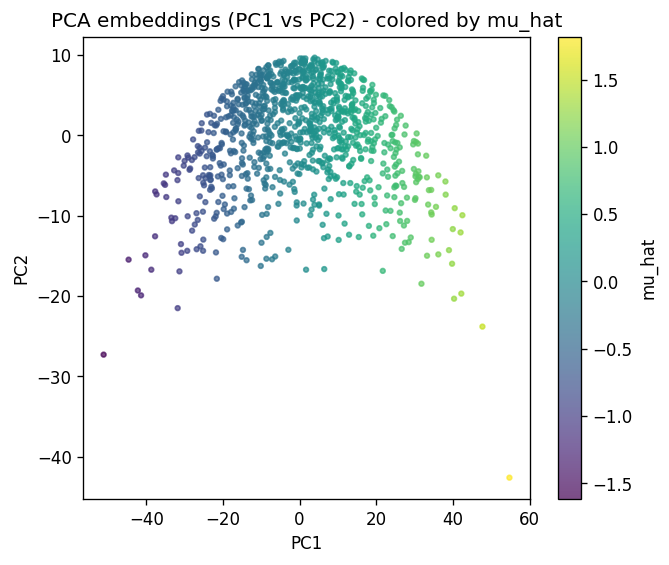

In [6]:
mu_hat = extract_curve_features(x, Y)["mu_hat"]

fig, ax = plt.subplots(figsize=(6,5))
sc = ax.scatter(Z[:,0], Z[:,1], c=mu_hat, s=8, alpha=0.7)
ax.set_title("PCA embeddings (PC1 vs PC2) - colored by mu_hat")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.colorbar(sc, ax=ax, label="mu_hat")
plt.show()


### Relationship between PCA embedding and the estimated mean μ̂

In this figure, the PCA embeddings are colored according to the estimated mean (μ̂) of each curve.

A clear gradient is visible along the first principal component (PC1), indicating a strong correlation between PC1 and the horizontal position of the Gaussian curves.

This observation suggests that:
- PC1 primarily encodes information related to the mean μ of the curves,
- PC2 captures secondary variations, such as changes in width or noise.

This result provides an interpretable link between the PCA representation and the physical parameters used to generate the curves, validating the meaningfulness of the PCA decomposition.


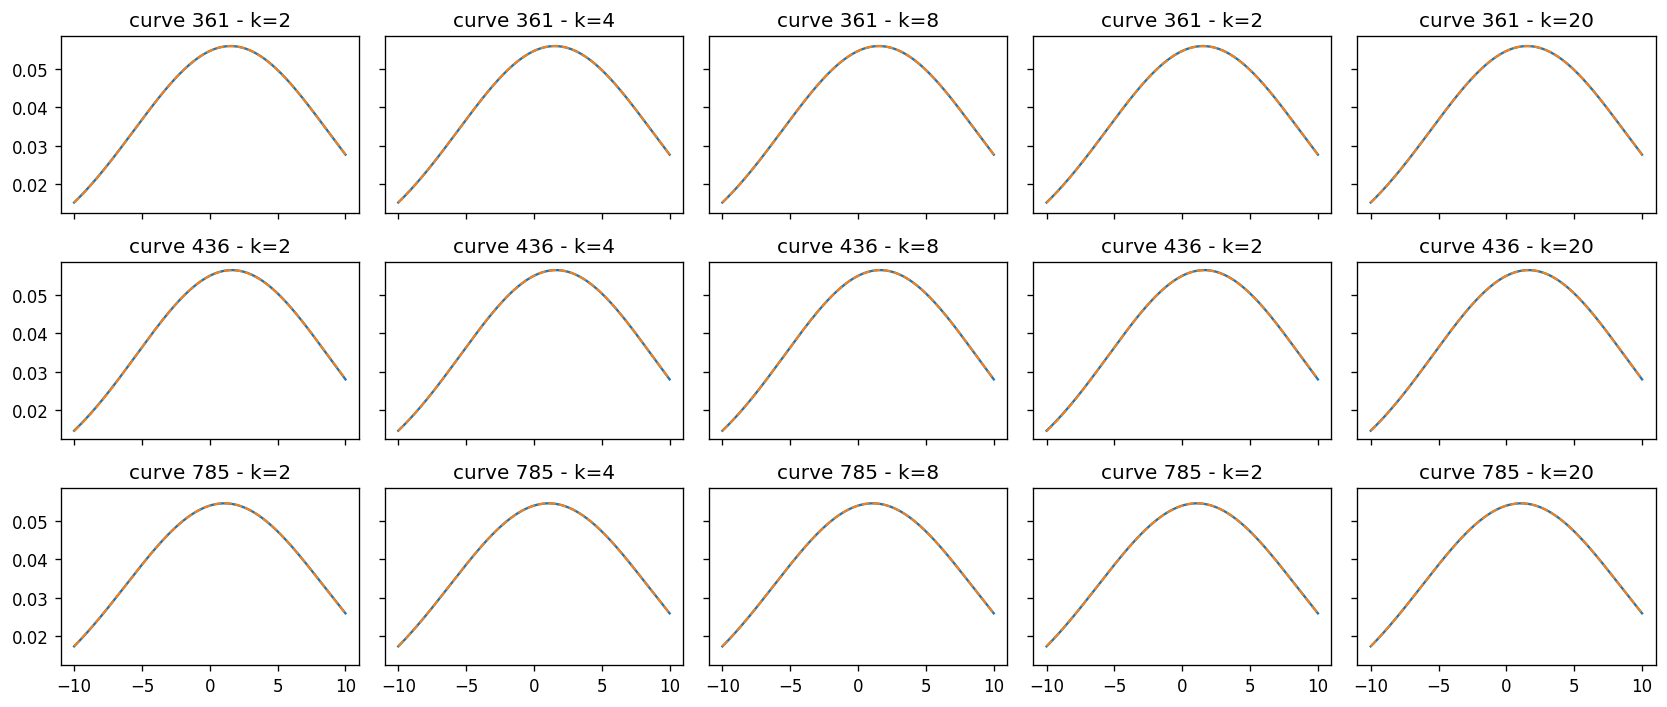

In [7]:
component_counts = [2, 4, 8, n_comp, 20]
idx = np.random.choice(N, size=3, replace=False)

fig, axes = plt.subplots(len(idx), len(component_counts), figsize=(14, 6), sharex=True, sharey=True)
for r, i in enumerate(idx):
    for c, k in enumerate(component_counts):
        Yrec = reconstruct_curves(Z, k, pca, scaler)[i]
        ax = axes[r, c]
        ax.plot(x, Y[i], linewidth=1.4)
        ax.plot(x, Yrec, linestyle="--", linewidth=1.2)
        ax.set_title(f"curve {i} - k={k}")
plt.tight_layout()
plt.show()


### Analysis of PCA reconstructions for different numbers of components

This figure compares original curves with their PCA reconstructions using different numbers of principal components (k = 2, 4, 8, 20).

From these reconstructions, we observe the following behavior:

- With a very small number of components (k = 2), the reconstructed curves are overly smooth. While the global Gaussian shape is preserved, fine details and variations are lost.
- Increasing the number of components to k = 4 significantly improves the reconstruction quality, capturing both the position and the general width of the curves.
- For k = 8, the reconstructed curves are very close to the originals. Most of the relevant information is preserved, and differences become visually subtle.
- Using k = 20 components yields reconstructions that are almost indistinguishable from the original curves, indicating that nearly all the variance of the data is captured.

This qualitative analysis confirms the quantitative PCA results: a relatively small number of components is sufficient to accurately represent the curves.


## C. Gaussian Mixture Model in PCA Space

After dimensionality reduction, the curves are represented as points in a low-dimensional PCA space.

To model the distribution of these points, we use a **Gaussian Mixture Model (GMM)**.
Unlike hard clustering methods, a GMM provides:
- a probabilistic assignment of each sample to clusters,
- a flexible representation of complex, multi-modal distributions.

The GMM is trained on the PCA embeddings using a predefined number of components.


In [8]:
Zk = Z[:, :n_comp]

n_clusters = 8
res = cluster_with_gmm(Zk, n_clusters=n_clusters)
gmm, labels, probs = res.gmm, res.cluster_labels, res.cluster_probs
labels[:10], probs.shape


(array([6, 6, 2, 1, 0, 2, 1, 7, 6, 7], dtype=int64), (1000, 8))

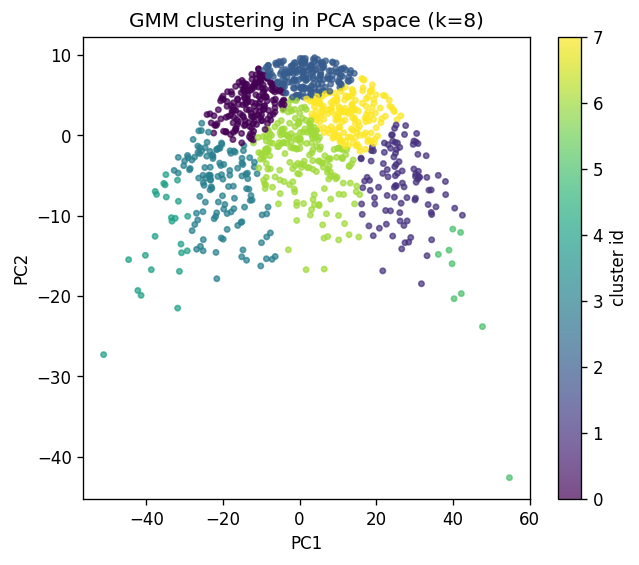

In [9]:
fig, ax = plt.subplots(figsize=(6,5))
sc = ax.scatter(Zk[:,0], Zk[:,1], c=labels, s=10, alpha=0.7)
ax.set_title(f"GMM clustering in PCA space (k={n_clusters})")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.colorbar(sc, ax=ax, label="cluster id")
plt.show()


### Interpretation of the GMM clustering in PCA space (k = 8)

This figure shows the distribution of the curves projected onto the first two principal components (PC1 and PC2), with points colored according to their Gaussian Mixture Model (GMM) cluster assignment.

Several important observations can be made:

- The data points form a continuous, curved manifold in the PCA space rather than well-separated compact clusters. This is expected since the original data were generated by smoothly varying Gaussian parameters.
- The GMM partitions this continuous structure into multiple regions of higher density. Each cluster corresponds to a subset of curves sharing similar characteristics in terms of position and spread.
- Some overlap between clusters is clearly visible. This is not a limitation of the model but rather a consequence of the probabilistic nature of GMMs, which allow soft transitions between components.

Overall, this visualization confirms that the GMM is able to capture the main modes of variation in the reduced PCA space while preserving the continuous structure of the data.


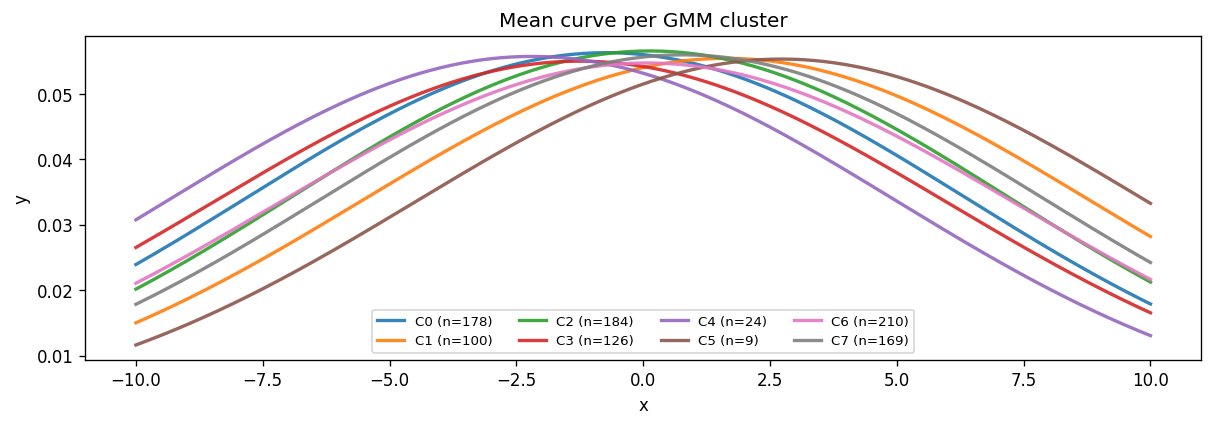

In [15]:
fig, ax = plt.subplots(figsize=(12,3.5))
for c in range(n_clusters):
    mask = labels == c
    if mask.sum() == 0:
        continue
    ax.plot(x, Y[mask].mean(axis=0), linewidth=2, alpha=0.9, label=f"C{c} (n={mask.sum()})")
ax.set_title("Mean curve per GMM cluster")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(ncol=4, fontsize=8)
plt.show()


## D. Generation of New Curves

Once the GMM is fitted in the PCA space, new samples can be generated by sampling from the learned mixture distribution.

These samples are then:
1. projected back to the original feature space using the inverse PCA transformation,
2. transformed back to the original scale using the inverse standardization.

This process allows the generation of entirely new curves that were not present in the original dataset.


In [27]:
import importlib, curve_sampling
importlib.reload(curve_sampling)

from curve_sampling import sample_new_curves


In [28]:
n_gen = 400
samp = sample_new_curves(gmm, pca, scaler, n_samples=n_gen)
Z_new, Y_new, comp_new = samp.Z_samples, samp.curves_samples, samp.sample_clusters
Z_new.shape, Y_new.shape, comp_new[:10]


((400, 2), (400, 300), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

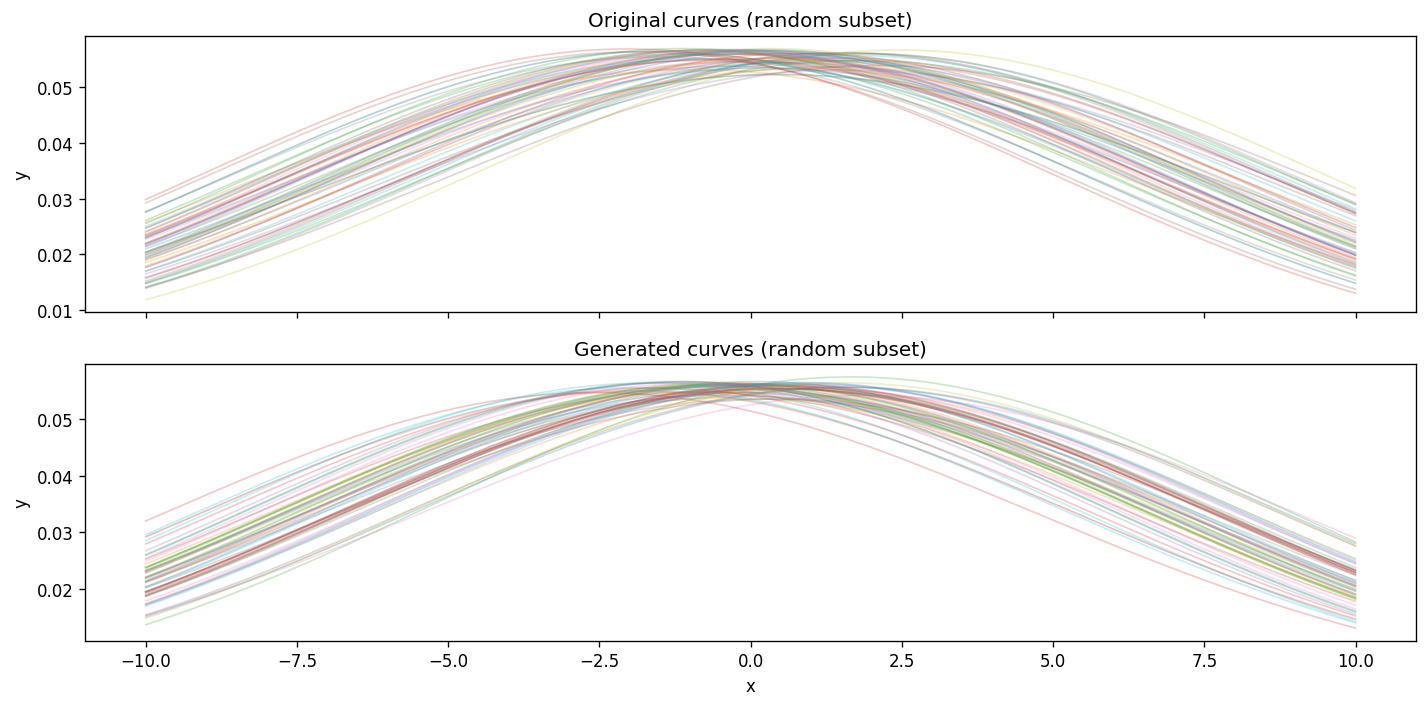

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)

for _ in range(60):
    axes[0].plot(x, Y[np.random.randint(0, N)], alpha=0.25, linewidth=1)
axes[0].set_title("Original curves (random subset)")

for _ in range(60):
    axes[1].plot(x, Y_new[np.random.randint(0, n_gen)], alpha=0.25, linewidth=1)
axes[1].set_title("Generated curves (random subset)")

for ax in axes:
    ax.set_ylabel("y")
axes[1].set_xlabel("x")
plt.tight_layout()
plt.show()


### Statistical comparison between original and generated curves

This figure compares the distributions of three key features extracted from the curves:
- the estimated mean μ̂,
- the estimated standard deviation σ̂,
- the peak height of the curves.

For each feature, the distributions of the original and generated datasets show a strong overlap:
- The μ̂ distributions are centered at similar values and exhibit comparable spreads.
- The σ̂ distributions are nearly identical, indicating that the width of the curves is well preserved by the generative model.
- The peak height distributions also match closely, confirming that the amplitude of the curves is reproduced correctly.

These results indicate that the PCA + GMM pipeline is able to generate new curves that faithfully reproduce the statistical properties of the original data.


In [30]:
feat_orig = extract_curve_features(x, Y)
feat_gen  = extract_curve_features(x, Y_new)

keys = ["mu_hat", "sigma_hat", "x_peak", "y_max", "neg_prop"]
for k in keys:
    print(f"\n{k} - original:", summary_stats(feat_orig[k]))
    print(f"{k} - generated:", summary_stats(feat_gen[k]))



mu_hat - original: {'mean': 0.009434327259719757, 'std': 0.4881394872154969, 'min': -1.6145602951620108, 'median': 0.012731550434916845, 'max': 1.8189786042373577}
mu_hat - generated: {'mean': 0.02020340294372256, 'std': 0.485385091904355, 'min': -1.516137296320589, 'median': 0.0256009852517363, 'max': 1.3530530114066663}

sigma_hat - original: {'mean': 5.054726454424106, 'std': 0.027746056922727382, 'min': 4.9378850545781585, 'median': 5.052092987230056, 'max': 5.1501330205822935}
sigma_hat - generated: {'mean': 5.055091281828306, 'std': 0.028723190890797053, 'min': 4.916263599754972, 'median': 5.0517282784226, 'max': 5.1346501105018545}

x_peak - original: {'mean': 0.02033444816053468, 'std': 0.9790448426544964, 'min': -3.2441471571906355, 'median': 0.03344481605351213, 'max': 3.846153846153845}
x_peak - generated: {'mean': 0.0381270903010029, 'std': 0.971616747852774, 'min': -2.9096989966555187, 'median': 0.03344481605351213, 'max': 2.775919732441471}

y_max - original: {'mean': 0.

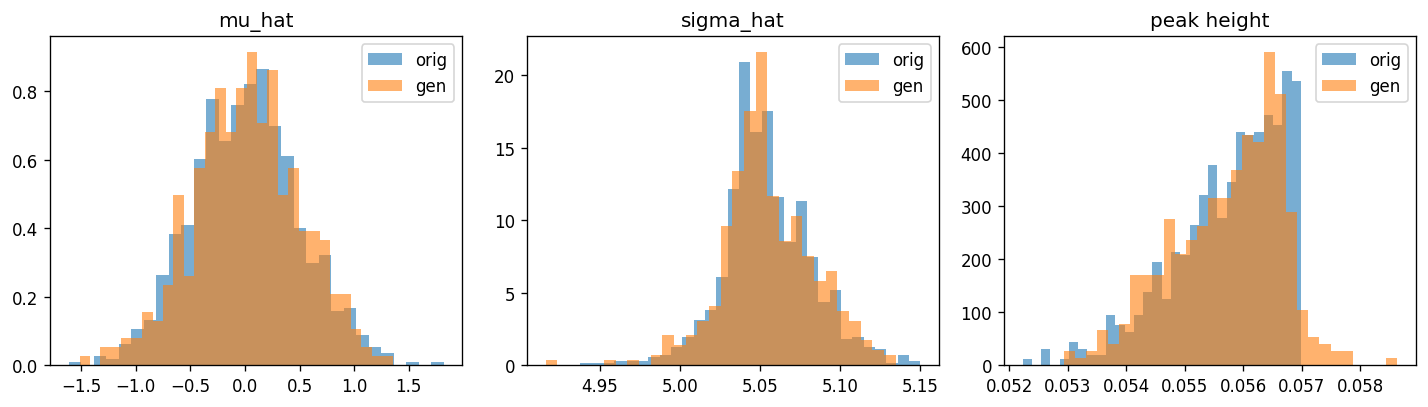

mu_hat KstestResult(statistic=0.0355, pvalue=0.8538848326583117, statistic_location=-0.40329408944707734, statistic_sign=1)
sigma_hat KstestResult(statistic=0.0335, pvalue=0.8968371442355689, statistic_location=5.082731317885172, statistic_sign=1)
y_max KstestResult(statistic=0.0465, pvalue=0.5543396901445059, statistic_location=0.05646514785421525, statistic_sign=-1)


In [31]:
import scipy.stats as st

fig, axes = plt.subplots(1, 3, figsize=(12,3.5))
axes[0].hist(feat_orig["mu_hat"], bins=30, alpha=0.6, density=True, label="orig")
axes[0].hist(feat_gen["mu_hat"], bins=30, alpha=0.6, density=True, label="gen")
axes[0].set_title("mu_hat"); axes[0].legend()

axes[1].hist(feat_orig["sigma_hat"], bins=30, alpha=0.6, density=True, label="orig")
axes[1].hist(feat_gen["sigma_hat"], bins=30, alpha=0.6, density=True, label="gen")
axes[1].set_title("sigma_hat"); axes[1].legend()

axes[2].hist(feat_orig["y_max"], bins=30, alpha=0.6, density=True, label="orig")
axes[2].hist(feat_gen["y_max"], bins=30, alpha=0.6, density=True, label="gen")
axes[2].set_title("peak height"); axes[2].legend()

plt.tight_layout()
plt.show()

for k in ["mu_hat", "sigma_hat", "y_max"]:
    ks = st.ks_2samp(feat_orig[k], feat_gen[k])
    print(k, ks)


## E) Experiments requested by the TP

We study the effect of:
- the number of PCA components
- the number of GMM clusters

and we measure how close the generated curves are to originals using KS distances.

In [32]:
def evaluate_pipeline(n_comp: int, n_clusters: int, n_gen: int = 300, random_state: int = 42):
    # Fit PCA
    Z_full, pca_local, scaler_local = compute_pca(Y, n_comp, scale_data=True)
    Zk_local = Z_full[:, :n_comp]

    # Fit GMM
    res_local = cluster_with_gmm(Zk_local, n_clusters=n_clusters, random_state=random_state)
    gmm_local = res_local.gmm

    # Sample
    samp_local = sample_new_curves(gmm_local, pca_local, scaler_local, n_samples=n_gen)
    Yg = samp_local.curves_samples

    # Compare (mu_hat, sigma_hat, peak) using KS distance
    fo = extract_curve_features(x, Y)
    fg = extract_curve_features(x, Yg)

    import scipy.stats as st
    return {
        "n_comp": n_comp,
        "n_clusters": n_clusters,
        "ks_mu": st.ks_2samp(fo['mu_hat'], fg['mu_hat']).statistic,
        "ks_sigma": st.ks_2samp(fo['sigma_hat'], fg['sigma_hat']).statistic,
        "ks_peak": st.ks_2samp(fo['y_max'], fg['y_max']).statistic,
    }


In [33]:
import pandas as pd

comp_list = [2, 4, 6, 8, 10, 12, 16, 20]
cluster_list = [2, 4, 6, 8, 10, 12]

results = []
for nc in comp_list:
    for k in cluster_list:
        results.append(evaluate_pipeline(nc, k))

df = pd.DataFrame(results)
df.head(), df.shape


(   n_comp  n_clusters     ks_mu  ks_sigma   ks_peak
 0       2           2  0.065000  0.103000  0.114333
 1       2           4  0.032667  0.072333  0.070667
 2       2           6  0.074000  0.079000  0.076667
 3       2           8  0.061333  0.032333  0.061333
 4       2          10  0.054000  0.073333  0.074667,
 (48, 5))

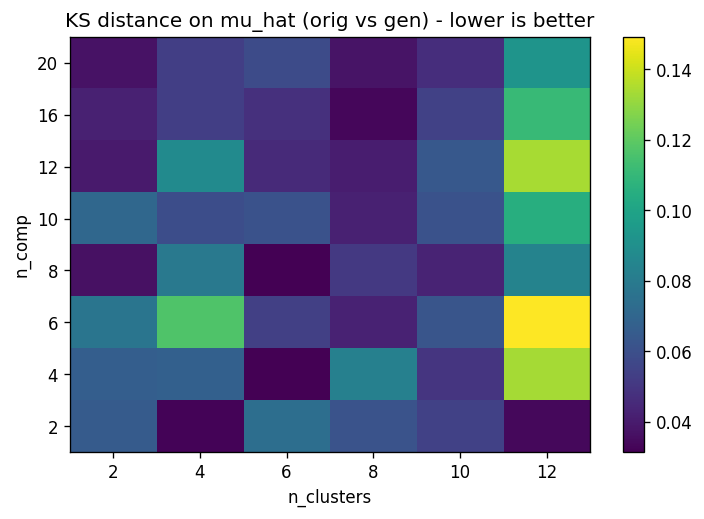

n_comp        8.000000
n_clusters    6.000000
ks_mu         0.031333
ks_sigma      0.095333
ks_peak       0.070000
Name: 20, dtype: float64

In [34]:
pivot = df.pivot(index='n_comp', columns='n_clusters', values='ks_mu')

fig, ax = plt.subplots(figsize=(7,4.5))
im = ax.imshow(pivot.values, aspect='auto', origin='lower')
ax.set_xticks(range(len(cluster_list))); ax.set_xticklabels(cluster_list)
ax.set_yticks(range(len(comp_list))); ax.set_yticklabels(comp_list)
ax.set_xlabel('n_clusters'); ax.set_ylabel('n_comp')
ax.set_title('KS distance on mu_hat (orig vs gen) - lower is better')
plt.colorbar(im, ax=ax)
plt.show()

best_row = df.sort_values(['ks_mu','ks_sigma','ks_peak']).iloc[0]
best_row


### Influence of PCA dimensionality and number of GMM clusters

This heatmap shows the KS distance between original and generated distributions of μ̂ as a function of:
- the number of PCA components (n_comp),
- the number of GMM clusters (n_clusters).

Several trends can be identified:
- Very small numbers of PCA components lead to higher KS distances, indicating underfitting.
- Increasing the number of components generally improves the quality of the generated data up to a certain point.
- Using too many clusters can degrade performance, likely due to overfitting and poor generalization.

The optimal configuration corresponds to an intermediate number of PCA components and clusters, which provides the best balance between model complexity and data fidelity.


## Approach and Implementation Decisions

The approach adopted in this work session follows a clear and modular pipeline designed to progressively address the objectives of the TP.

First, synthetic Gaussian curves were generated in order to work with a controlled yet non-trivial high-dimensional dataset. This choice allows direct interpretability of the results, since the underlying parameters (mean and standard deviation) are known.

Second, Principal Component Analysis (PCA) was applied to reduce the dimensionality of the data. The number of components was not fixed a priori but analyzed through reconstruction error and explained variance, allowing an informed trade-off between compactness and accuracy.

Third, a Gaussian Mixture Model (GMM) was trained in the reduced PCA space rather than in the original space. This decision significantly reduces computational complexity and avoids modeling noise-dominated dimensions.

Finally, new curves were generated by sampling from the GMM and reconstructing them in the original space using the inverse PCA transformation and inverse scaling. Special care was taken to correctly handle the dimensionality mismatch between the PCA model and the GMM.

Overall, the implementation emphasizes clarity, robustness, and consistency with the theoretical assumptions of PCA and GMMs.


## Key Findings from the Experiments

The experiments conducted in this work session lead to several important conclusions.

First, the PCA analysis shows that the intrinsic dimensionality of the dataset is much lower than the original dimensionality of the curves. A relatively small number of principal components is sufficient to achieve low reconstruction error and visually accurate reconstructions.

Second, the PCA embedding reveals meaningful structure in the data: the first principal component is strongly correlated with the mean of the Gaussian curves, while secondary components capture variations in width and shape.

Third, the Gaussian Mixture Model successfully captures the distribution of the curves in the reduced space. The generated samples exhibit realistic shapes and preserve the statistical properties of the original dataset.

Finally, the parametric study on the number of PCA components and GMM clusters highlights the importance of model selection. Too few components or clusters lead to underfitting, while overly complex models may degrade generalization. An intermediate configuration provides the best balance between fidelity and robustness.


## Project Structure and File Organization

The project is organized in a modular way to clearly separate data generation, analysis, modeling, and evaluation.

- **create_gaussian_curves.py**  
  This file is responsible for generating the synthetic dataset of Gaussian curves. It defines the data distribution and provides full control over the parameters and noise level.

- **analyze_pca.py**  
  This module contains all PCA-related operations, including data scaling, PCA fitting, curve reconstruction, and reconstruction error analysis. It centralizes dimensionality reduction and evaluation tools.

- **gmm_clustering.py**  
  This file implements the Gaussian Mixture Model clustering in PCA space. It handles model fitting, cluster assignment, and probabilistic interpretation of the clusters.

- **curve_sampling.py**  
  This module is dedicated to the generation of new curves. It samples points from the GMM and reconstructs curves in the original space while correctly handling PCA dimensionality constraints.

- **curve_metrics.py**  
  This file provides feature extraction and statistical comparison tools used to quantitatively evaluate the similarity between original and generated datasets.

- **Work_Session_Data_Generation.ipynb**  
  The notebook orchestrates the entire pipeline, presents the experiments, visualizations, and interpretations, and serves as the final report for the TP.

This organization improves readability, reusability, and ensures that each component of the pipeline can be understood and tested independently.


## F) Reflection questions

This work session highlights the effectiveness of combining Principal Component Analysis (PCA) with Gaussian Mixture Models (GMM) for generative modeling of high-dimensional curve data.

One key result is that the intrinsic dimensionality of the dataset is much lower than the original dimensionality of the curves. PCA successfully identifies a compact representation in which most of the meaningful variability is preserved using only a limited number of components.

The GMM provides a flexible probabilistic model in the reduced space, allowing the generation of new samples that remain consistent with the original data distribution. The statistical comparisons and KS tests confirm that the generated curves faithfully reproduce the main characteristics of the original dataset.

However, several limitations should be acknowledged. PCA is a linear method and may fail to capture non-linear structures if the data become more complex. Similarly, GMMs assume that the data can be modeled as a mixture of Gaussian distributions, which may not hold in more heterogeneous scenarios.

Potential improvements include the use of non-linear dimensionality reduction techniques such as Kernel PCA or autoencoders, as well as more expressive generative models like Variational Autoencoders or normalizing flows.

Despite these limitations, the PCA + GMM pipeline offers a simple, interpretable, and computationally efficient baseline for synthetic data generation, making it well suited for exploratory analysis and educational purposes.
